# Sub Graphs

    - Sub Graph in langgraph means a graph that is embedded and executed as node inside another graph

# 1 - Sub Graph invoked inside one node -> Separate graph state

In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

In [15]:
from langchain.chat_models import init_chat_model

subgraph_llm = init_chat_model(
    model="gemma3:4b",
    model_provider="ollama",
    temperature = 0
    )
parent_llm = init_chat_model(
    model="gemma3:4b",
    model_provider="ollama",
    temperature = 0
    )

In [6]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [7]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [8]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [9]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [10]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [11]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [12]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

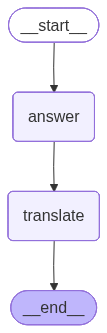

In [13]:
graph = parent_builder.compile()

graph

In [14]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Okay, let\'s break down quantum physics. It’s a notoriously tricky subject, but here’s a clear explanation:\n\n**In a nutshell, quantum physics (also called quantum mechanics) is the branch of physics that deals with the incredibly small – atoms and the particles within them.** It describes how these tiny things behave, and it’s fundamentally different from the physics we experience in our everyday lives (classical physics).\n\nHere’s a breakdown of the key concepts:\n\n**1. Quantization:**\n\n* **The Core Idea:** The word "quantum" comes from the Latin word for "amount" or "discrete unit." This means that energy, momentum, angular momentum, and other properties aren\'t continuous like a ramp, but come in specific, fixed amounts called *quanta*.\n* **Example:** Think of a staircase instead of a ramp. You can only stand on specific steps, not in between. Similarly, an electron can only have certain, specific energy levels within an

# 2-Sub graph included as node in another graph -> Same Graph state

In [17]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [18]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [19]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [20]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [21]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

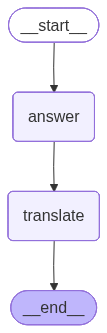

In [22]:
graph = parent_builder.compile()

graph

In [23]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Okay, let\'s break down quantum physics. It’s a notoriously tricky subject, but here’s a clear explanation:\n\n**In a nutshell, quantum physics (also called quantum mechanics) is the branch of physics that deals with the incredibly small – atoms and the particles within them.** It describes how these tiny things behave, and it’s fundamentally different from the physics we experience in our everyday lives (classical physics).\n\nHere’s a breakdown of the key concepts:\n\n**1. Quantization:**\n\n* **The Core Idea:** The word "quantum" comes from the Latin word for "amount" or "discrete unit." This means that energy, momentum, angular momentum, and other properties aren\'t continuous like a ramp, but come in specific, fixed amounts called *quanta*.\n* **Example:** Think of a staircase instead of a ramp. You can only stand on specific steps, not in between. Similarly, an electron can only have certain, specific energy levels within an